# 01 - Bivariate analysis for binary target and amount

This notebook builds simple bivariate views across all variables except:
- `Opportunity Number`
- `Deal Size Category (USD)`
- `Opportunity Result` (initial target)

Rules implemented:
- Binary target (`Opportunity Result Bool`) vs continuous: **violinplots**
- Binary target vs categoricals: **barplots of Won mean rate by level**
- Amount (`Opportunity Amount USD`) vs categoricals: **violinplots**
- Amount vs continuous: **hexbin density** + **cut bins with group mean table/plot**

In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 200)
sns.set_theme(style='whitegrid')

In [10]:
df_load = pd.read_parquet('../../data/intermediate/df_train_stratified.parquet')
print('shape:', df_load.shape)
df_load.head(2)

shape: (53073, 24)


,Opportunity Number,Supplies Group,Supplies Subgroup,Region,Route To Market,Elapsed Days In Sales Stage,Opportunity Result,Sales Stage Change Count,Total Days Identified Through Closing,Total Days Identified Through Qualified,Opportunity Amount USD,Client Size By Revenue (USD),Client Size By Employee Count,Revenue From Client Past Two Years (USD),Competitor Type,Ratio Days Identified To Total Days,Ratio Days Validated To Total Days,Ratio Days Qualified To Total Days,Deal Size Category (USD),total_days_zero,Opportunity Result Bool,opportunity_amount_weirdness,amount_qbin,stratify_key
0,9406532,Car Accessories,Batteries & Accessories,Midwest,Reseller,25,Loss,1,0,0,92024,100K or less,1K or less,0 (No business),Unknown,0.0,0.0,0.0,30K to 40K,True,False,4.855807,"(65789.0, 100000.0]","0__(65789.0, 100000.0]"
1,9953365,Car Accessories,Garage & Car Care,Pacific,Reseller,3,Won,3,2,2,1550,100K or less,1K or less,0 (No business),NaN,0.0,1.0,0.0,10K or less,False,True,6.842306,"(0.999, 6500.0]","1__(0.999, 6500.0]"


In [15]:
columns_to_use = ['Supplies Group', 'Supplies Subgroup', 'Region',
       'Route To Market', 'Elapsed Days In Sales Stage', 'Opportunity Result',
       'Sales Stage Change Count', 'Total Days Identified Through Closing',
       'Total Days Identified Through Qualified', 'Opportunity Amount USD',
       'Client Size By Revenue (USD)', 'Client Size By Employee Count',
       'Revenue From Client Past Two Years (USD)', 'Competitor Type',
       'Ratio Days Identified To Total Days',
       'Ratio Days Validated To Total Days',
       'Ratio Days Qualified To Total Days', 'Deal Size Category (USD)', "Opportunity Result Bool"]

df = df_load[columns_to_use].copy()

In [16]:
binary_target = 'Opportunity Result Bool'
amount_target = 'Opportunity Amount USD'
excluded = {'Opportunity Number', 'Deal Size Category (USD)', 'Opportunity Result'}

all_predictors = [c for c in df.columns if c not in excluded]

def is_array_like_object(series: pd.Series) -> bool:
    non_null = series.dropna()
    if non_null.empty:
        return False
    return isinstance(non_null.iloc[0], (list, tuple, set, dict, np.ndarray))

binary_continuous_cols = [
    c for c in all_predictors
    if c != binary_target and pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_bool_dtype(df[c])
]
binary_categorical_cols = [
    c for c in all_predictors
    if c != binary_target and (
        pd.api.types.is_bool_dtype(df[c])
        or pd.api.types.is_object_dtype(df[c])
        or pd.api.types.is_categorical_dtype(df[c])
        or pd.api.types.is_string_dtype(df[c])
    )
]

amount_continuous_cols = [
    c for c in all_predictors
    if c != amount_target and pd.api.types.is_numeric_dtype(df[c]) and not pd.api.types.is_bool_dtype(df[c])
]
amount_categorical_cols = [
    c for c in all_predictors
    if c != amount_target and (
        pd.api.types.is_bool_dtype(df[c])
        or pd.api.types.is_object_dtype(df[c])
        or pd.api.types.is_categorical_dtype(df[c])
        or pd.api.types.is_string_dtype(df[c])
    )
]

print('binary continuous vars:', len(binary_continuous_cols))
print('binary categorical vars:', len(binary_categorical_cols))
print('amount continuous vars:', len(amount_continuous_cols))
print('amount categorical vars:', len(amount_categorical_cols))

binary continuous vars: 8
binary categorical vars: 8
amount continuous vars: 7
amount categorical vars: 9


/var/folders/1b/ylrjkq_n52n_y9f5l6h05h_m0000gn/T/ipykernel_11259/1617910131.py:22: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[c])
/var/folders/1b/ylrjkq_n52n_y9f5l6h05h_m0000gn/T/ipykernel_11259/1617910131.py:36: Pandas4Warning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  or pd.api.types.is_categorical_dtype(df[c])


## Binary target vs continuous variables (violinplots)

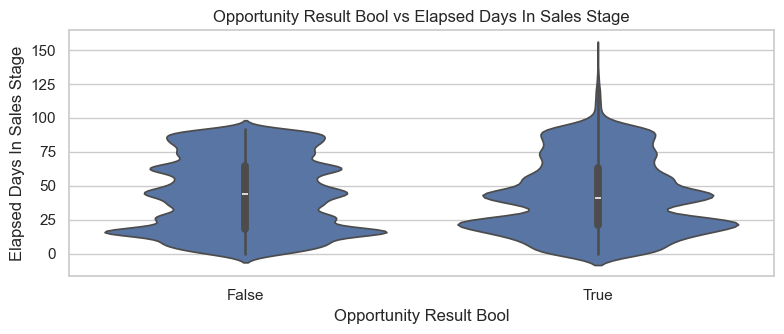

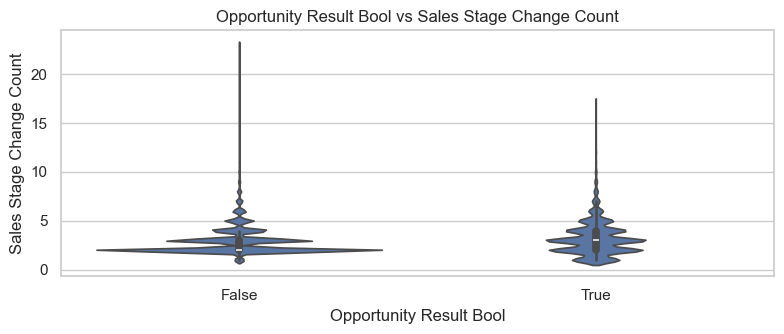

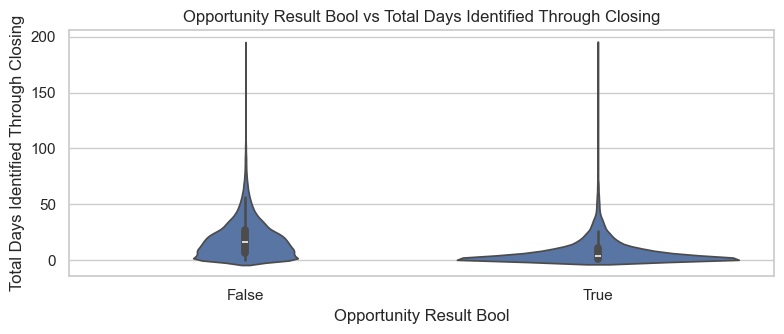

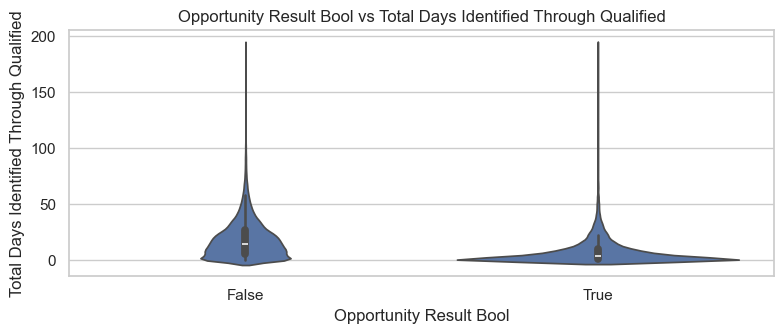

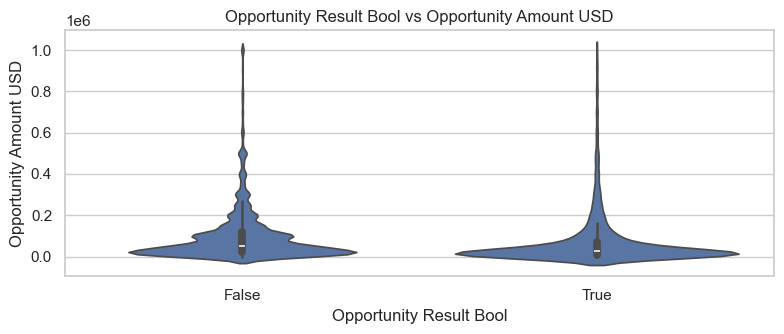

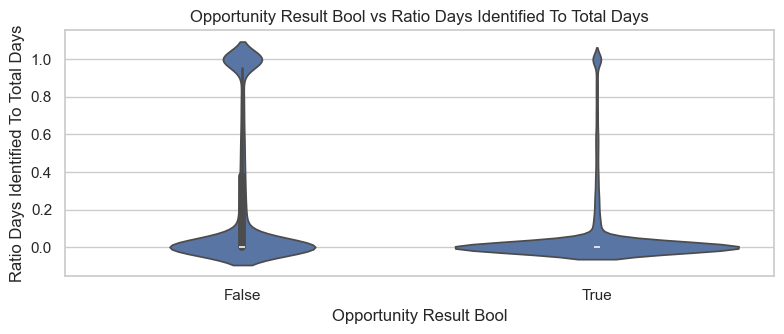

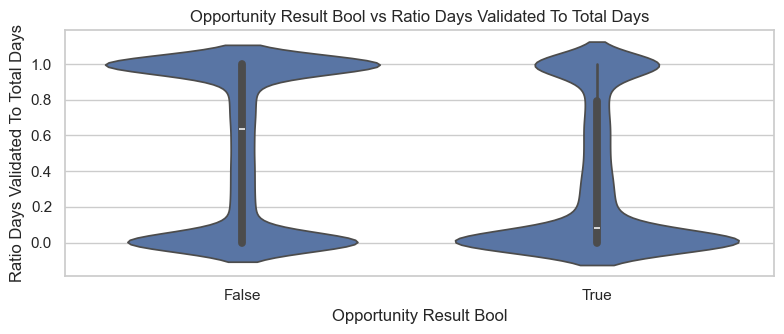

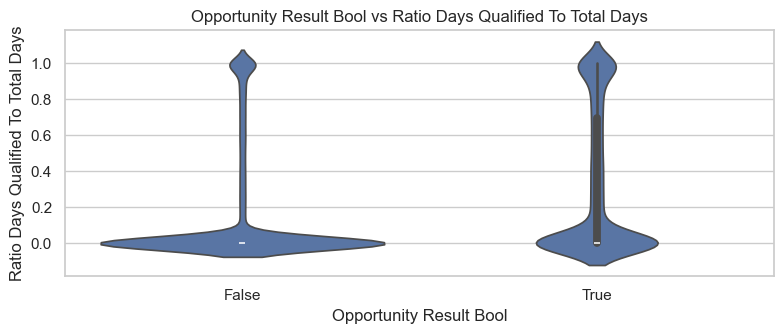

In [21]:
for col in binary_continuous_cols:
    tmp = df[[binary_target, col]].replace([np.inf, -np.inf], np.nan).dropna()
    if tmp.empty:
        print(f'[skip] {col}: no valid rows')
        continue

    plt.figure(figsize=(8, 3.5))
    sns.hist(data=tmp, x=binary_target, y=col)
    plt.title(f'{binary_target} vs {col}')
    plt.xlabel(binary_target)
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

## Binary target vs categorical variables (Won mean rate by level)

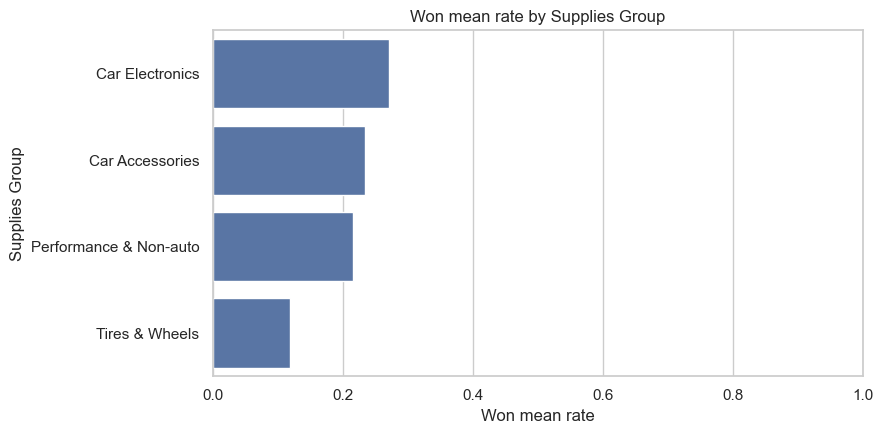

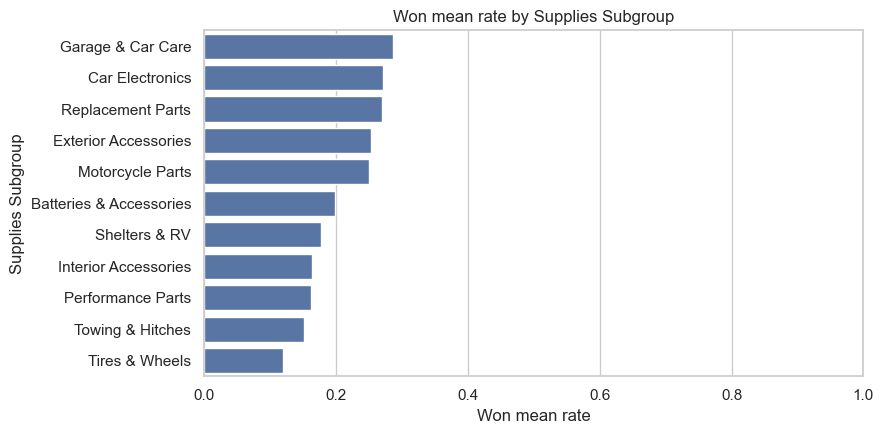

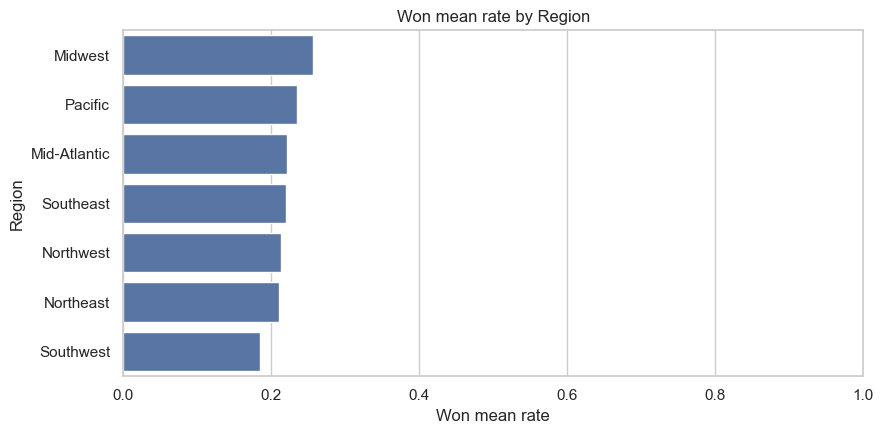

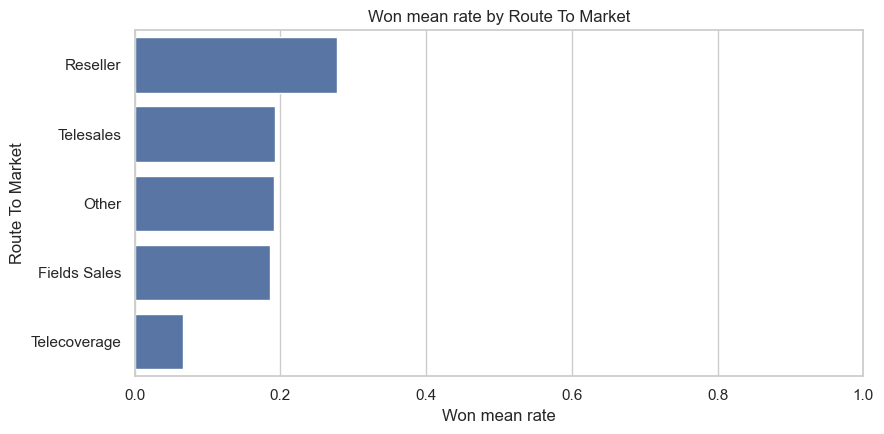

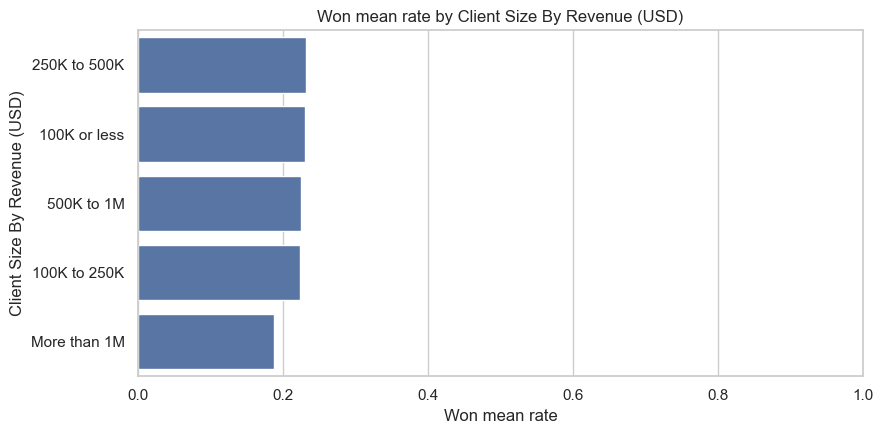

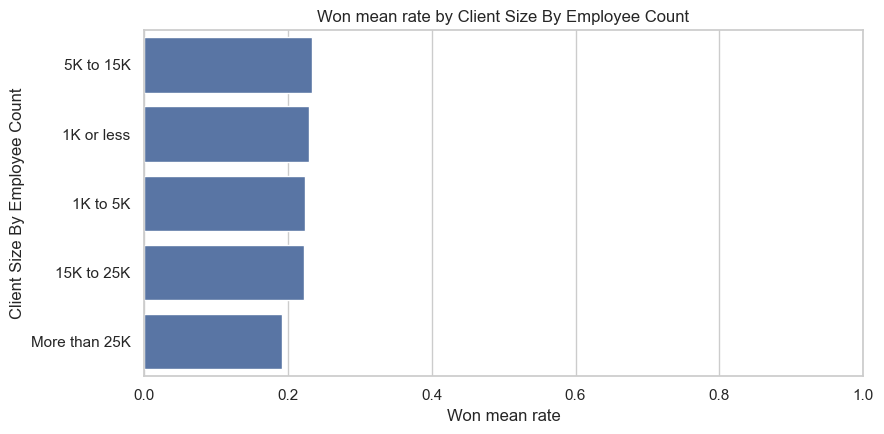

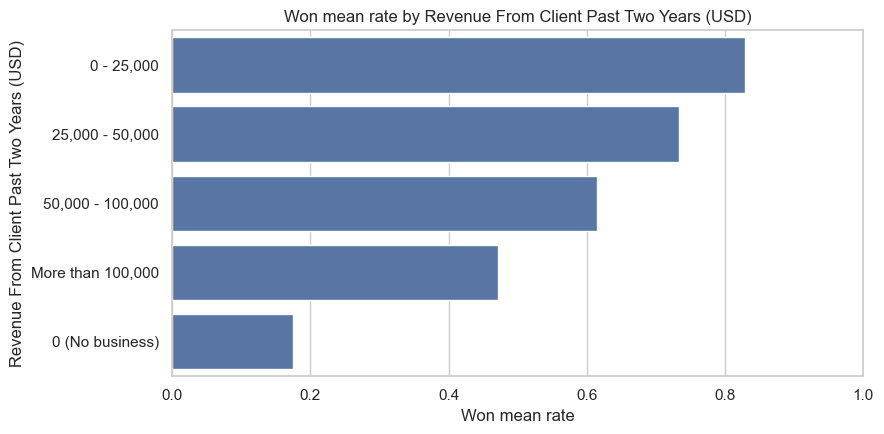

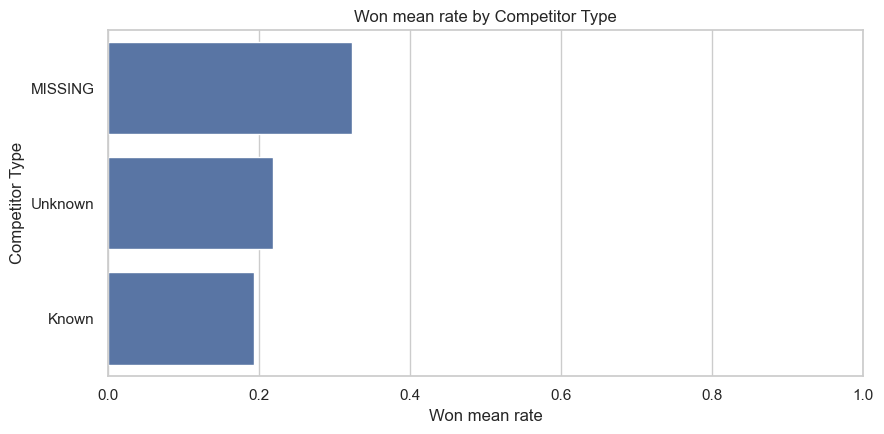

In [6]:
for col in binary_categorical_cols:
    s = df[col]
    if is_array_like_object(s):
        print(f'[skip] {col}: array-like values are not suitable for level barplots')
        continue

    tmp = df[[col, binary_target]].dropna(subset=[binary_target]).copy()
    tmp[col] = tmp[col].astype(str).fillna('MISSING')

    # keep chart readable
    top_levels = tmp[col].value_counts().head(15).index
    tmp = tmp[tmp[col].isin(top_levels)].copy()

    rate_tbl = (
        tmp.groupby(col, observed=False)[binary_target]
        .mean()
        .sort_values(ascending=False)
        .reset_index(name='won_rate')
    )

    plt.figure(figsize=(9, 4.5))
    sns.barplot(data=rate_tbl, y=col, x='won_rate', orient='h')
    plt.title(f'Won mean rate by {col}')
    plt.xlabel('Won mean rate')
    plt.ylabel(col)
    plt.xlim(0, 1)
    plt.tight_layout()
    plt.show()

## Amount vs categorical variables (violinplots)

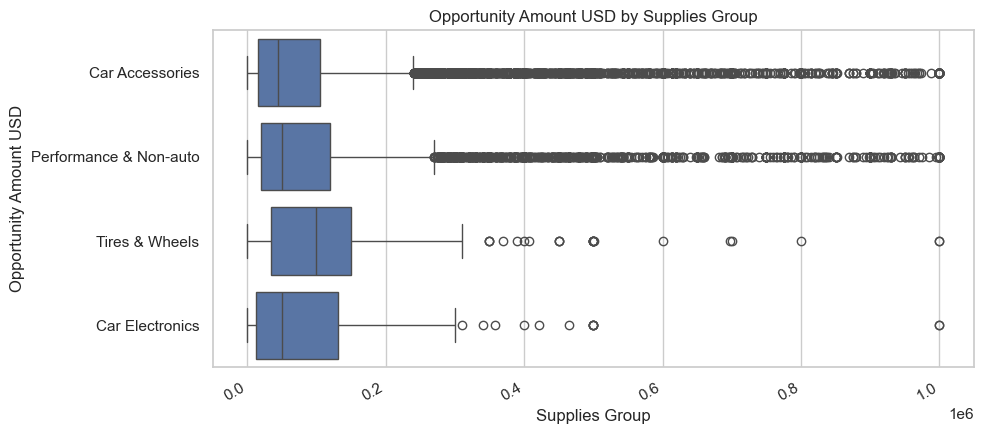

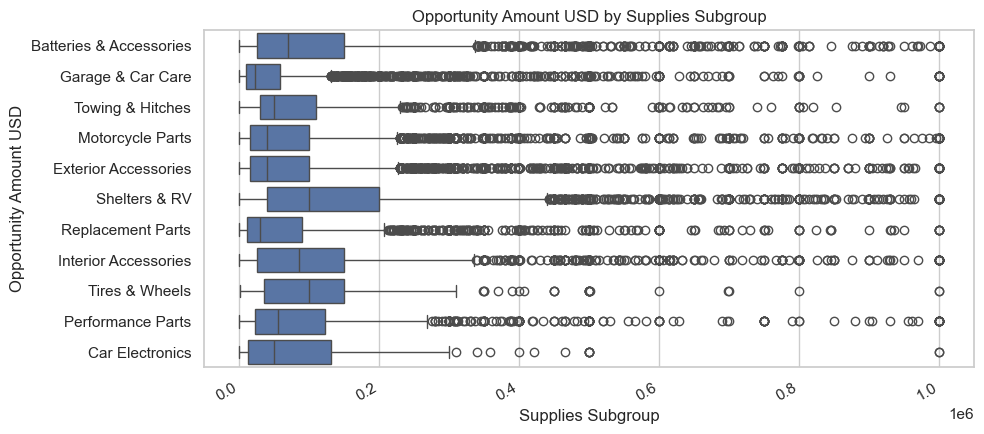

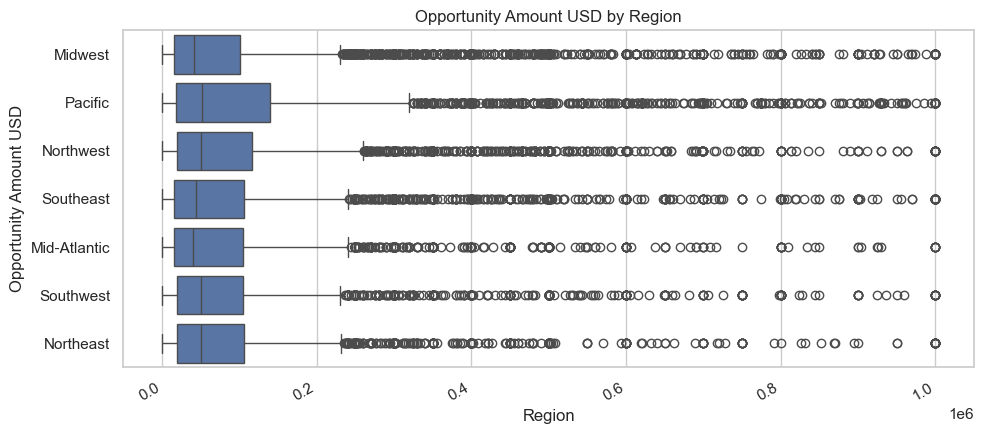

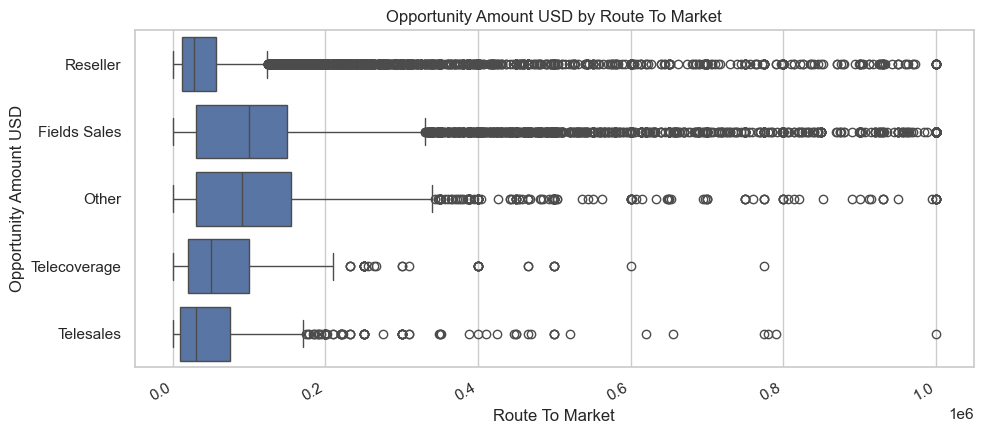

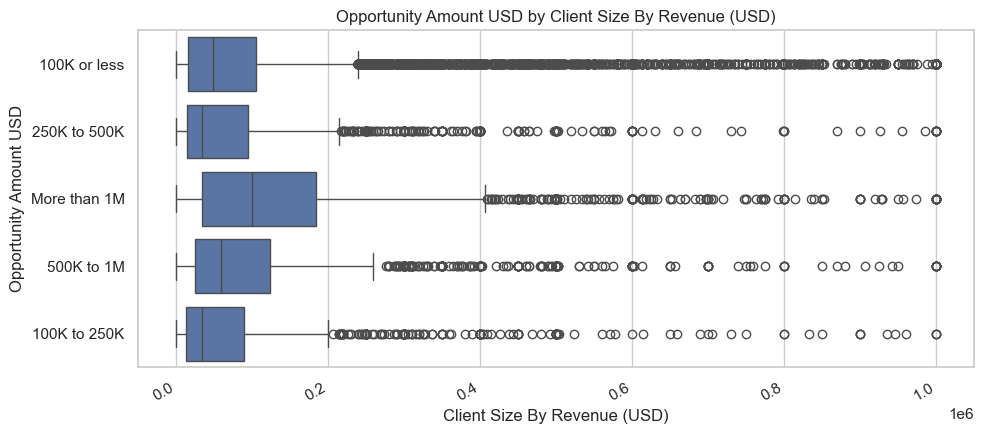

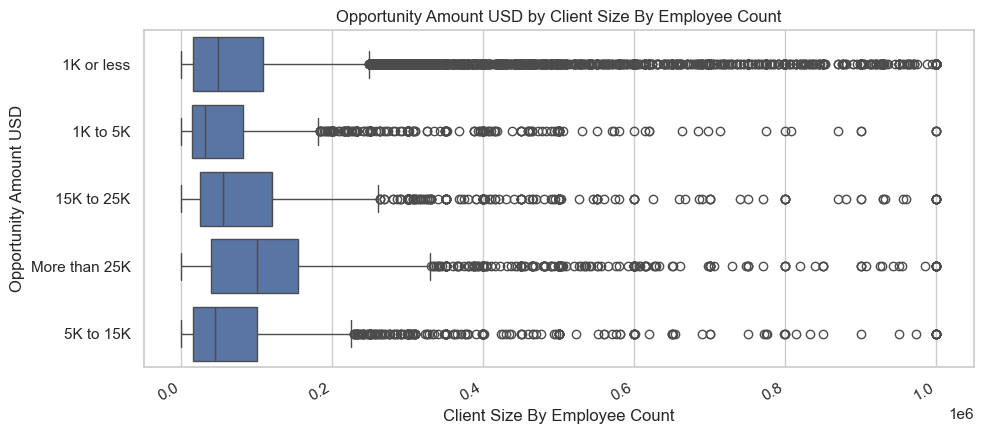

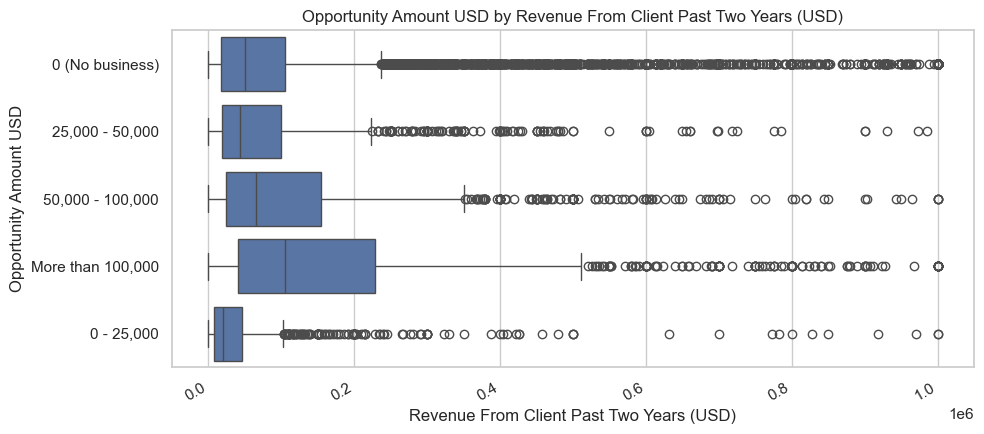

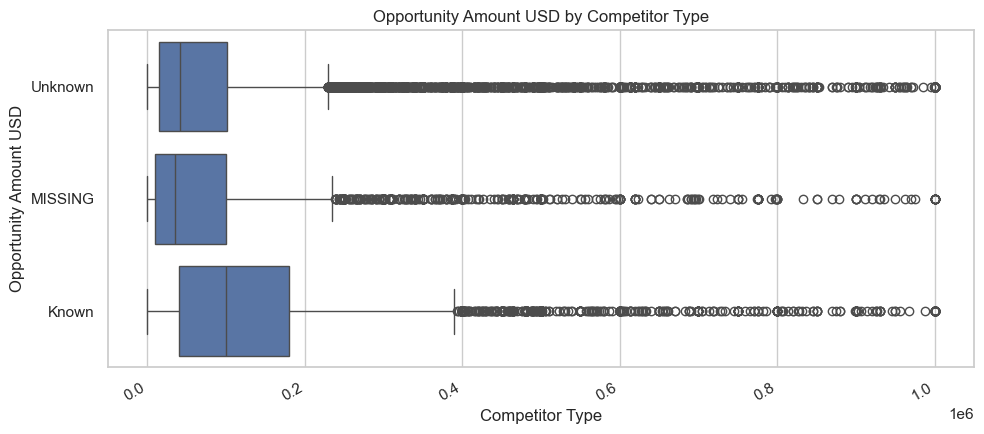

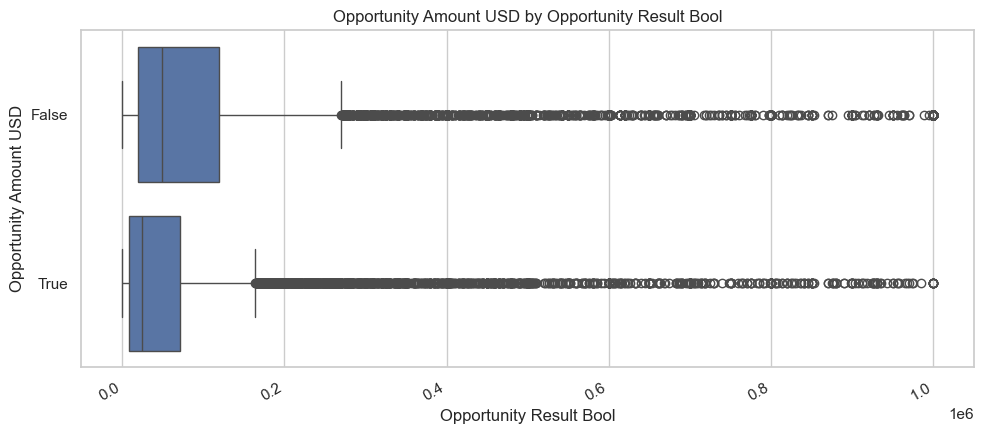

In [23]:
for col in amount_categorical_cols:
    s = df[col]
    if is_array_like_object(s):
        print(f'[skip] {col}: array-like values are not suitable for categorical violinplots')
        continue

    tmp = df[[col, amount_target]].replace([np.inf, -np.inf], np.nan).dropna(subset=[amount_target]).copy()
    tmp[col] = tmp[col].astype(str).fillna('MISSING')

    top_levels = tmp[col].value_counts().head(15).index
    tmp = tmp[tmp[col].isin(top_levels)].copy()

    if tmp.empty:
        print(f'[skip] {col}: no valid rows after filtering')
        continue

    plt.figure(figsize=(10, 4.5))
    sns.boxplot(data=tmp, y=col, x=amount_target)
    plt.title(f'{amount_target} by {col}')
    plt.xlabel(col)
    plt.ylabel(amount_target)
    plt.xticks(rotation=30, ha='right')
    plt.tight_layout()
    plt.show()

## Amount vs continuous variables (hexbin + cut/groupby mean)

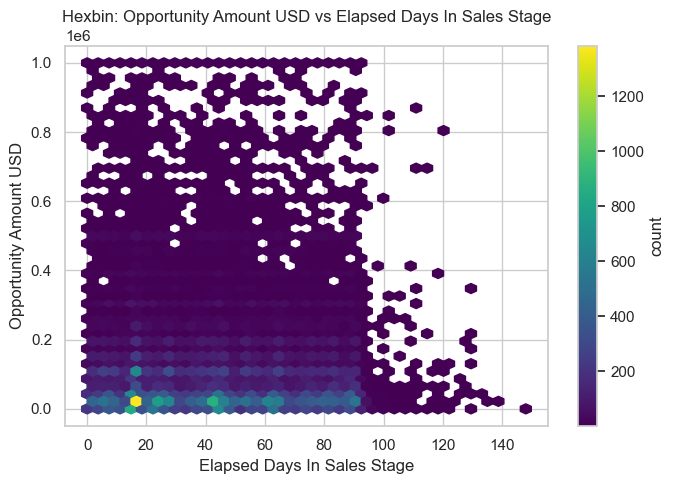

Groupby cut table for Elapsed Days In Sales Stage


,_bin,count,mean,median
0,"(-0.148, 14.8]",7692,96819.032891,50000.0
1,"(14.8, 29.6]",12432,93166.054376,50000.0
2,"(29.6, 44.4]",8431,95773.559839,50000.0
3,"(44.4, 59.2]",7874,97991.860808,50000.0
4,"(59.2, 74.0]",7877,93301.171004,50000.0
5,"(74.0, 88.8]",6257,89588.623462,50000.0
6,"(88.8, 103.6]",2422,86367.183732,45814.0
7,"(103.6, 118.4]",51,130631.254902,55000.0
8,"(118.4, 133.2]",33,99499.333333,49501.0
9,"(133.2, 148.0]",4,20005.750000,19500.0


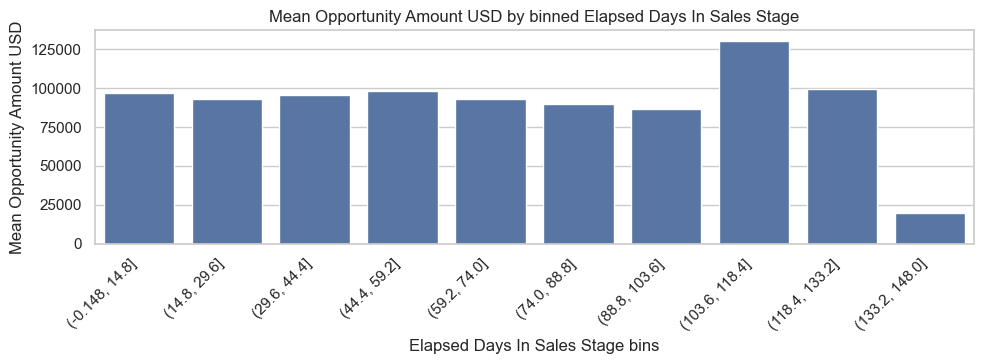

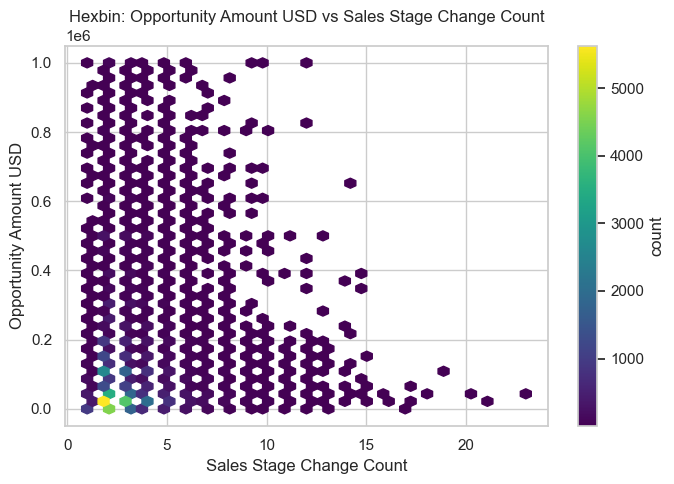

Groupby cut table for Sales Stage Change Count


,_bin,count,mean,median
0,"(0.978, 3.2]",40163,90890.385006,50000.0
1,"(3.2, 5.4]",9742,103204.020324,50000.0
2,"(5.4, 7.6]",2224,105992.686151,50000.0
3,"(7.6, 9.8]",641,114235.606864,58139.0
4,"(9.8, 12.0]",236,107334.872881,50000.0
5,"(12.0, 14.2]",42,114730.523810,67250.0
6,"(14.2, 16.4]",15,94407.933333,50000.0
7,"(16.4, 18.6]",6,29308.500000,22984.0
8,"(18.6, 20.8]",2,70000.000000,70000.0
9,"(20.8, 23.0]",2,22500.000000,22500.0


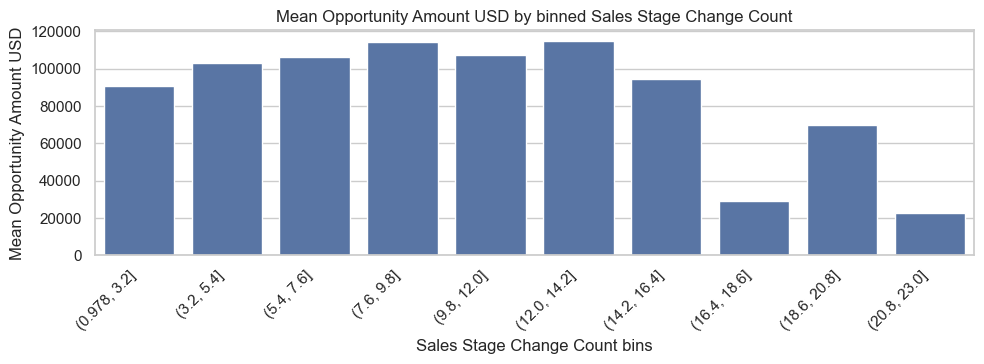

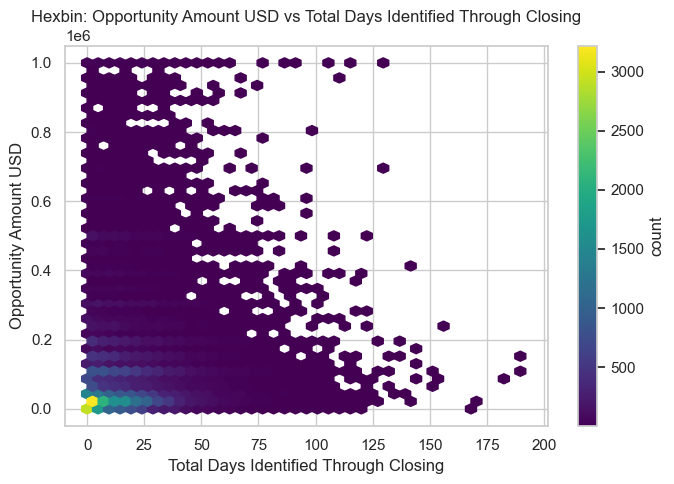

Groupby cut table for Total Days Identified Through Closing


,_bin,count,mean,median
0,"(-0.192, 19.2]",35002,89452.198874,41000.0
1,"(19.2, 38.4]",12875,96903.052660,50000.0
2,"(38.4, 57.6]",3662,114841.499454,70000.0
3,"(57.6, 76.8]",1064,123084.211466,75000.0
4,"(76.8, 96.0]",317,134386.772871,100000.0
5,"(96.0, 115.2]",100,152132.880000,100000.0
6,"(115.2, 134.4]",33,197862.303030,95000.0
7,"(134.4, 153.6]",14,115327.214286,77507.0
8,"(153.6, 172.8]",3,94000.000000,29000.0
9,"(172.8, 192.0]",3,113255.666667,109767.0


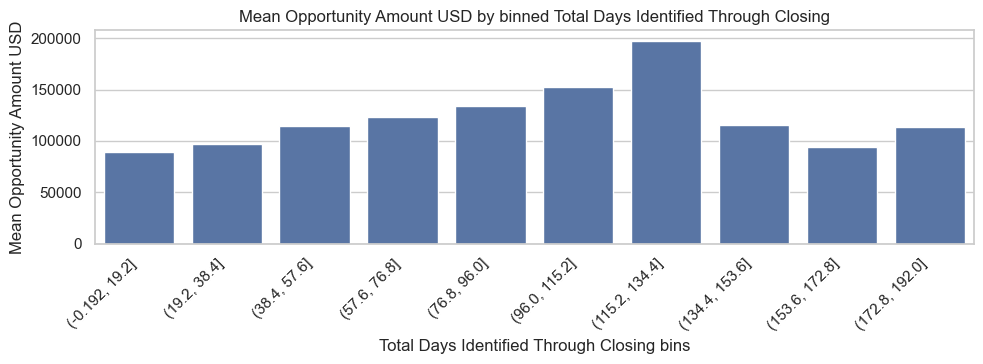

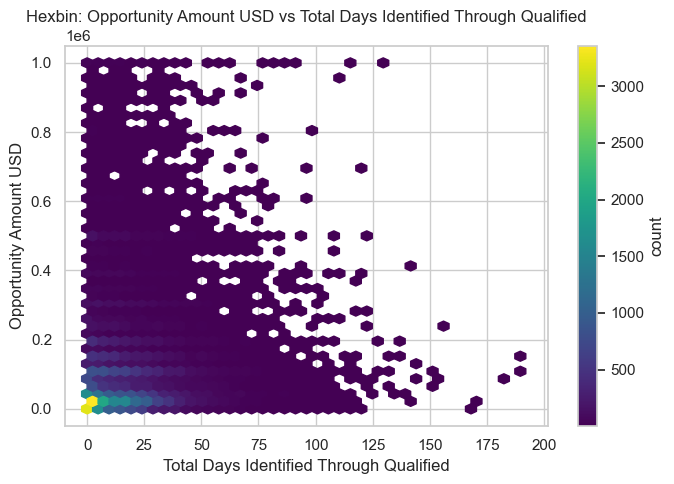

Groupby cut table for Total Days Identified Through Qualified


,_bin,count,mean,median
0,"(-0.192, 19.2]",35413,89551.538079,41000.0
1,"(19.2, 38.4]",12631,96894.488718,50000.0
2,"(38.4, 57.6]",3586,115300.845231,70000.0
3,"(57.6, 76.8]",1009,125001.961348,77507.0
4,"(76.8, 96.0]",293,136752.293515,100000.0
5,"(96.0, 115.2]",93,144362.956989,98795.0
6,"(115.2, 134.4]",29,220990.241379,100000.0
7,"(134.4, 153.6]",13,110781.769231,77507.0
8,"(153.6, 172.8]",3,94000.000000,29000.0
9,"(172.8, 192.0]",3,113255.666667,109767.0


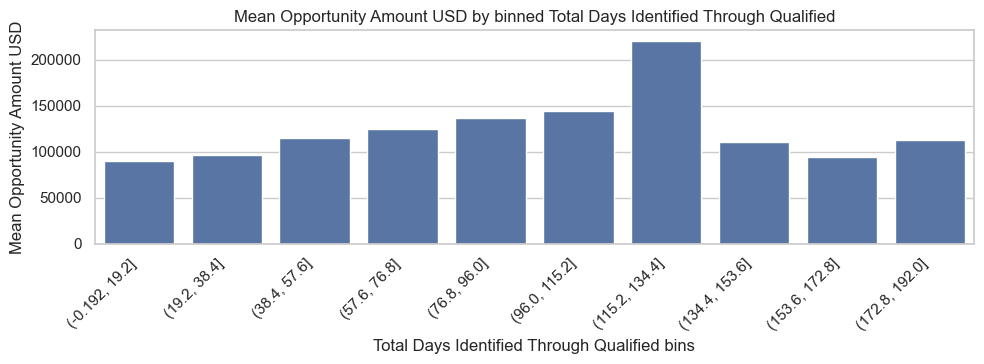

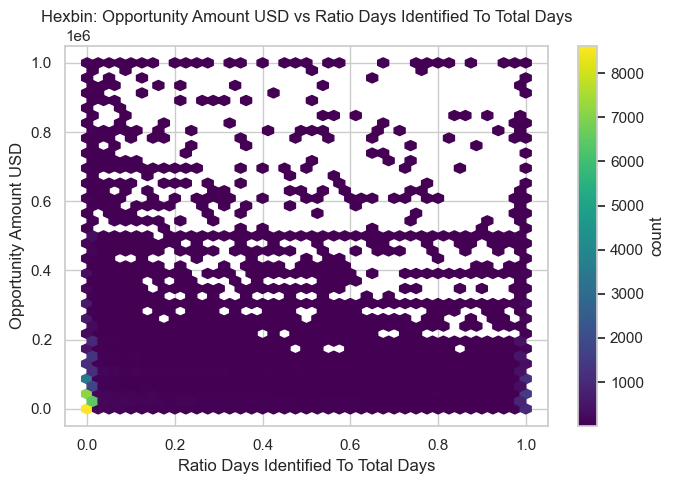

Groupby cut table for Ratio Days Identified To Total Days


,_bin,count,mean,median
0,"(-0.001, 0.1]",38210,86457.920204,40000.0
1,"(0.1, 0.2]",1703,117817.551967,80000.0
2,"(0.2, 0.3]",1249,120819.118495,70000.0
3,"(0.3, 0.4]",1030,119099.120388,70000.0
4,"(0.4, 0.5]",865,118256.119075,77507.0
5,"(0.5, 0.6]",763,120134.844037,75000.0
6,"(0.6, 0.7]",597,119412.463987,77507.0
7,"(0.7, 0.8]",558,116986.236559,71428.0
8,"(0.8, 0.9]",453,114061.066225,62000.0
9,"(0.9, 1.0]",7645,109451.444212,70000.0


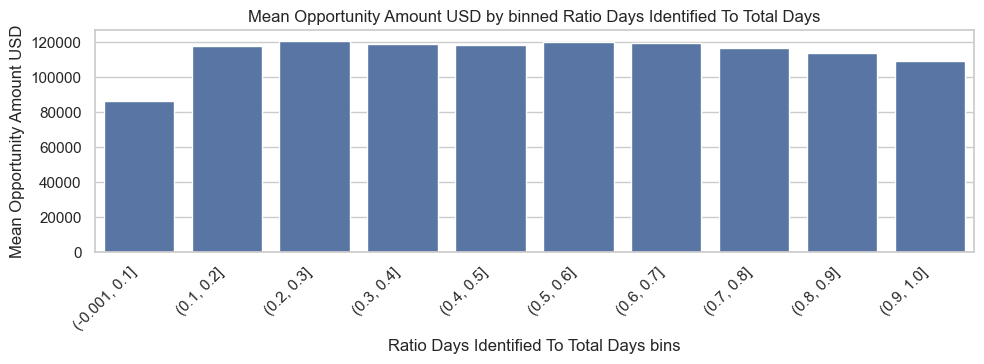

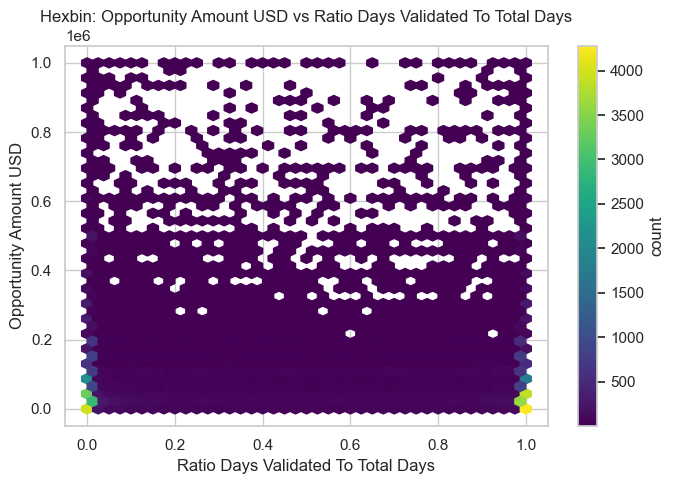

Groupby cut table for Ratio Days Validated To Total Days


,_bin,count,mean,median
0,"(-0.001, 0.1]",20716,95704.058699,50000.0
1,"(0.1, 0.2]",1834,119795.078517,60000.0
2,"(0.2, 0.3]",1575,117973.564444,65434.0
3,"(0.3, 0.4]",1538,119557.617685,70000.0
4,"(0.4, 0.5]",1479,119170.114266,65000.0
5,"(0.5, 0.6]",1398,114685.839056,70000.0
6,"(0.6, 0.7]",1448,112064.723757,60000.0
7,"(0.7, 0.8]",1492,112373.897453,60240.0
8,"(0.8, 0.9]",1581,110936.792536,60240.0
9,"(0.9, 1.0]",20012,79093.546822,36809.0


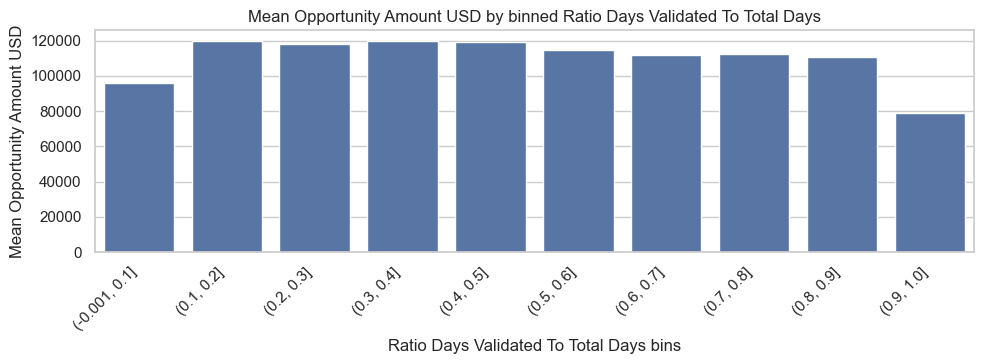

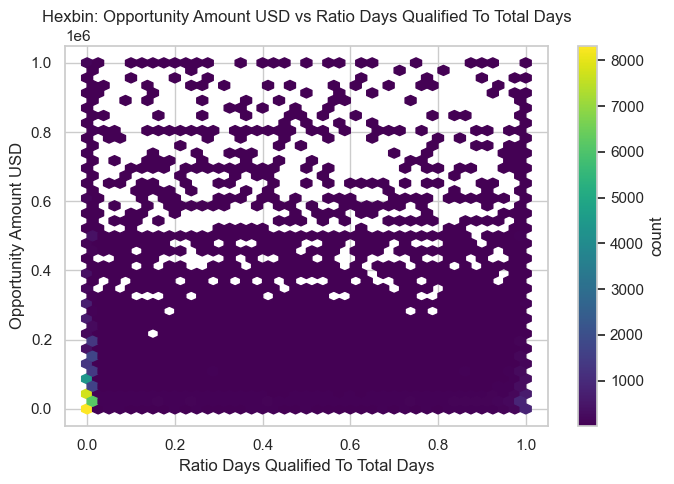

Groupby cut table for Ratio Days Qualified To Total Days


,_bin,count,mean,median
0,"(-0.001, 0.1]",38802,88064.624220,49000.0
1,"(0.1, 0.2]",1092,124386.698718,56500.0
2,"(0.2, 0.3]",1128,129971.848404,77507.0
3,"(0.3, 0.4]",1092,120239.645604,61674.5
4,"(0.4, 0.5]",1088,127795.778493,65394.5
5,"(0.5, 0.6]",1039,131311.375361,75000.0
6,"(0.6, 0.7]",1048,121002.182252,64000.0
7,"(0.7, 0.8]",1120,116899.511607,60000.0
8,"(0.8, 0.9]",1220,114920.081148,56962.0
9,"(0.9, 1.0]",5444,90463.852314,40000.0


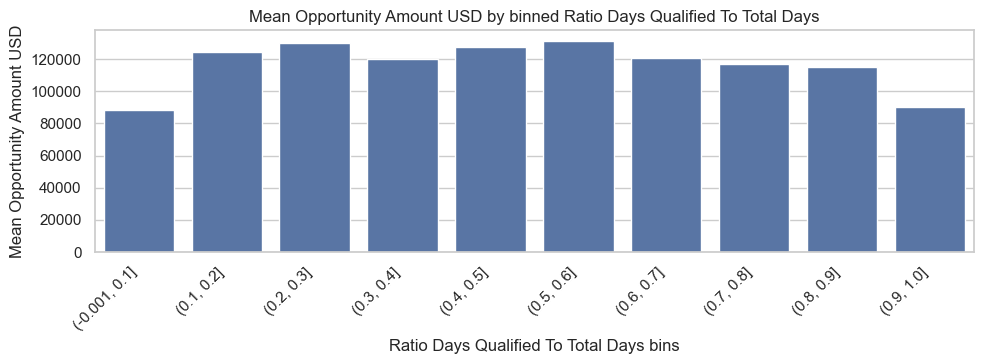

In [8]:
for col in amount_continuous_cols:
    tmp = df[[col, amount_target]].replace([np.inf, -np.inf], np.nan).dropna()
    if tmp.empty:
        print(f'[skip] {col}: no valid rows')
        continue

    if tmp[col].nunique(dropna=True) < 5:
        print(f'[skip] {col}: too few unique values for continuous view')
        continue

    plt.figure(figsize=(7, 5))
    hb = plt.hexbin(tmp[col], tmp[amount_target], gridsize=40, cmap='viridis', mincnt=1)
    plt.colorbar(hb, label='count')
    plt.title(f'Hexbin: {amount_target} vs {col}')
    plt.xlabel(col)
    plt.ylabel(amount_target)
    plt.tight_layout()
    plt.show()

    tmp['_bin'] = pd.cut(tmp[col], bins=10, duplicates='drop')
    bin_tbl = (
        tmp.groupby('_bin', observed=False)[amount_target]
        .agg(['count', 'mean', 'median'])
        .reset_index()
    )
    print(f'Groupby cut table for {col}')
    display(bin_tbl)

    bin_tbl['bin_label'] = bin_tbl['_bin'].astype(str)
    plt.figure(figsize=(10, 3.8))
    sns.barplot(data=bin_tbl, x='bin_label', y='mean')
    plt.title(f'Mean {amount_target} by binned {col}')
    plt.xlabel(f'{col} bins')
    plt.ylabel(f'Mean {amount_target}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()